# HyperParameters Optimization, 3 steps Neural Network

In [13]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from keras.utils import custom_object_scope
from keras.initializers import glorot_uniform
from keras.models import save_model#, load_model
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3D import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import os
from itertools import product
import keras
import tensorflow as tf

In [14]:
# reproducibility
seed=42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data preparation

In [15]:
NepoLF = 500  # number of epochs for first NN: NN_LF
NepoLin = 1500  # number of epochs for second NN: NN_Lin
NepoHF = 1000  # number of epochs for second NN: NN_HF
Nlf = 100
n_HF=10

########################     PREPARATION      ##########################
# introduction of the data
file_path_LF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_LF_46_d75.mat")
(reaction_LF_test, U_LF_test, t_LF_test) = import_data(file_path_LF)
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test, t_HF_test)= import_data(file_path_HF)
t_LF_test=t_LF_test.T
t_HF_test=t_HF_test.T



In [16]:
reaction_HF_test=normalization(reaction_HF_test)
reaction_LF_test=normalization(reaction_LF_test)
t_HF_test=normalization(t_HF_test)
t_LF_test=normalization(t_LF_test)


In [17]:


U_HF_test = U_HF_test[:, :, 44,44]
U_HF_test = normalization(U_HF_test)

U_LF_test = U_LF_test[:, :, 12,12]
U_LF_test = normalization(U_LF_test)


In [18]:
# TRANSFORMATION

permutation1 = np.random.permutation(len(reaction_LF_test))
permutation2 = np.random.permutation(len(t_LF_test))

reaction_LF = reaction_LF_test[permutation1][0:Nlf]
t_LF = t_LF_test[permutation2][0:Nlf]

grid1, grid2 = np.meshgrid(reaction_LF, t_LF)
reaction_LF = np.column_stack((grid1.ravel(), grid2.ravel()))
reaction_LF_test = np.array(list(product(reaction_LF_test.flatten(), t_LF_test.flatten())))

reaction_LF=np.c_[reaction_LF, np.abs(np.sin(3.5*np.pi*reaction_LF[:, 1])),np.ones(reaction_LF.shape[0])]
reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(3.5*np.pi*reaction_LF_test[:, 1])),np.ones(reaction_LF_test.shape[0])]

##
p1, p2 = np.meshgrid(permutation1[0:Nlf], permutation2[0:Nlf])
permutation = np.column_stack((p1.ravel(), p2.ravel()))
U_LF = U_LF_test[permutation[:,0],permutation[:,1]] 
row, col = U_LF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_LF_test = U_LF_test.flatten()[comb]
##

In [19]:
# TRANSFORMATION

permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(t_HF_test))

reaction_HF = reaction_HF_test[permutation1][0:n_HF]
t_HF = t_HF_test[permutation2][0:n_HF]

grid1, grid2 = np.meshgrid(reaction_HF, t_HF)
reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))
reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), t_HF_test.flatten())))

reaction_HF=np.c_[reaction_HF, np.abs(np.sin(3.5*np.pi*reaction_HF[:, 1])),np.ones(reaction_HF.shape[0])]
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(3.5*np.pi*reaction_HF_test[:, 1])),np.ones(reaction_HF_test.shape[0])]

##
p1, p2 = np.meshgrid(permutation1[0:n_HF], permutation2[0:n_HF])
permutation = np.column_stack((p1.ravel(), p2.ravel()))
U_HF = U_HF_test[permutation[:,0],permutation[:,1]] 
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test = U_HF_test.flatten()[comb]
##

# Neural Network
## Low Fidelity NN 

In [20]:
##########################       FIRST NN: NN_LF     ##########################

K.clear_session()
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
}  # where do they come from

modelLF = getModel(bestLF_params, "LF")
histLF = modelLF.fit(
    reaction_LF, U_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
)
print("LF NN done")

ULF = modelLF.predict(reaction_LF_test)
print("\nLF Model:")

test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
print(f"Test MSE: {test_mse}")

r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
    np.square(U_LF_test - np.mean(U_LF_test))
)
print(f"R^2: {r_2}")

LF NN done
1252/1252 [==============================] - 2s 1ms/step

LF Model:
Test MSE: 0.12112688678253482
R^2: -1.045395846466235e-05


1252/1252 [==============================] - 2s 2ms/step


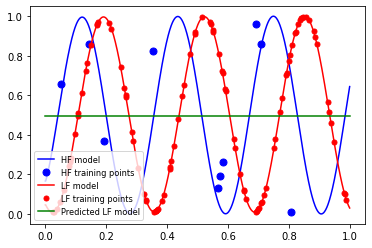

1252/1252 [==============================] - 2s 2ms/step


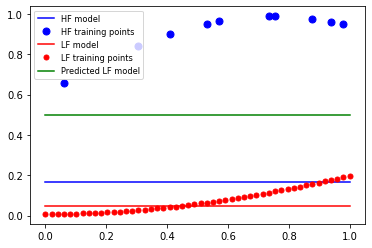

In [21]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
index_order=np.argsort(reaction_HF_test[:,0])
index_order_HF=np.argsort(reaction_HF[:,0])  
index_order_LF=np.argsort(reaction_LF[:,0])   

mask1_test=np.where(reaction_HF_test[:,0]==reaction_HF_test[:,0][index_order[2]])
mask1=np.where(reaction_LF_test[:,0]==np.min(reaction_LF_test[:,0]))
mask1_HF=np.where(reaction_HF[:,0]==reaction_HF[:,0][index_order_HF[2]])
mask1_LF=np.where(reaction_LF[:,0]==reaction_LF[:,0][index_order_LF[2]])
order=np.argsort(reaction_LF[mask1_HF,1])


plt.plot(reaction_HF_test[mask1_test,1].T, U_HF_test[mask1_test], "b-", linewidth=1.5, label="HF model")
plt.plot(
    reaction_HF[mask1_HF,1].T,
    U_HF[mask1_HF],
    "bo",
    markersize=7,
    label="HF training points",
)
plt.plot(reaction_LF_test[mask1,1].T, U_LF_test[mask1], "r-", linewidth=1.5, label="LF model")
plt.plot(
    reaction_LF[mask1_LF,1].T,
    U_LF[mask1_LF],
    "ro",
    markersize=5,
    label="LF training points",
)

plt.plot(
    reaction_LF_test[mask1,1].T,
    modelLF.predict(reaction_LF_test)[mask1],
    "g-",
    label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.show()


plt.figure()
index_order=np.argsort(reaction_HF_test[:,1])
index_order_HF=np.argsort(reaction_HF[:,1])  
index_order_LF=np.argsort(reaction_LF[:,1])   

mask1_test=np.where(reaction_HF_test[:,1]==reaction_HF_test[:,1][index_order[2]])
mask1=np.where(reaction_LF_test[:,1]==np.min(reaction_LF_test[:,1]))
mask1_HF=np.where(reaction_HF[:,1]==reaction_HF[:,1][index_order_HF[2]])
mask1_LF=np.where(reaction_LF[:,1]==reaction_LF[:,1][index_order_LF[2]])
order=np.argsort(reaction_LF[mask1_HF,0])


plt.plot(reaction_HF_test[mask1_test,0].T, U_HF_test[mask1_test], "b-", linewidth=1.5, label="HF model")
plt.plot(
    reaction_HF[mask1_HF,0].T,
    U_HF[mask1_HF],
    "bo",
    markersize=7,
    label="HF training points",
)
plt.plot(reaction_LF_test[mask1,0].T, U_LF_test[mask1], "r-", linewidth=1.5, label="LF model")
plt.plot(
    reaction_LF[mask1_LF,0].T,
    U_LF[mask1_LF],
    "ro",
    markersize=5,
    label="LF training points",
)

plt.plot(
    reaction_LF_test[mask1,0].T,
    modelLF.predict(reaction_LF_test)[mask1],
    "g-",
    label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.show()




In [22]:
print(f"\n-------  #HF data = {n_HF}  -------")
start = perf_counter()

##########################    SECOND NN: NN_Lin    ##########################
reaction_test_help = modelLF.predict(reaction_LF_test)[:, 0]
reaction_test_in = np.concatenate(
            (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
            )    # <- TEST INPUT for the second NN: NN_HF

reaction_train_help = modelLF.predict(reaction_HF)[:, 0]  # f_LF(mu_hf_train)
reaction_lin = np.concatenate(
            (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
            )  # <- TRAINING INPUT for the second NN: NN_HF

bestLin_params = {
    "lr": 0.001,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
    "l2weight": 0.01,
}
modelLin = getModel(bestLin_params, "Hflin")
histLin = modelLin.fit(
    reaction_lin,
    U_HF,
    validation_data=(reaction_test_in, U_HF_test),
    epochs=NepoLin,
    batch_size=n_HF,
    verbose=0,
    validation_freq=50,
)

ULin = modelLin.predict(
    np.concatenate(
            (reaction_LF_test, reaction_test_help.reshape(-1,1)),axis=1
            )  
)



-------  #HF data = 10  -------
  25/1252 [..............................] - ETA: 2s  

1252/1252 [==============================] - 3s 2ms/step


In [23]:
##########################    THIRD NN: NN_HF    ##########################
# Input for training NN_HF
reaction_help1 = modelLin.predict(reaction_lin)[:, 0]
reaction_final = np.concatenate(
            (reaction_HF, reaction_train_help.reshape(-1,1),reaction_help1.reshape(-1,1)),axis=1
            )  

# Input for testing NN_HF
reaction_test_help1 = modelLin.predict(reaction_test_in)[:, 0]
reaction_test_final = np.concatenate(
            (reaction_LF_test, reaction_test_help.reshape(-1,1),reaction_test_help1.reshape(-1,1)),axis=1
            )  

name = "3step"

4/4 [==============================] - 0s 2ms/step


1252/1252 [==============================] - 2s 2ms/step


In [24]:
####################    HYPERPARAMETER OPTIMIZATION    #######################
MAX_EVAL = 30

K.clear_session()
bayes_trials = Trials()
opt_list = ["Adam", "Adamax"]
kernel_list = ["uniform", "glorot_uniform"]
aux_dic = {"opt": opt_list, "kernel_init": kernel_list}
space = {
    "nodes": hp.qloguniform("nodes", np.log(4), np.log(64), 2),
    "l2weight": hp.loguniform("l2weight", np.log(0.0001), np.log(1)),
    "lr": hp.loguniform("lr", np.log(0.0001), np.log(0.1)),
    "kernel_init": hp.choice("kernel_init", kernel_list),
    "opt": hp.choice("opt", opt_list),
}


def objective(params):
    K.clear_session()
    CVres = kCrossVal(2,n_HF, NepoHF, reaction_final, U_HF, params, name)
    return {"loss": CVres, "params": params, "status": STATUS_OK}


# The following call will optimize and select the best parameters:
best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=MAX_EVAL,
    trials=bayes_trials,
)

transfBestparam(best_params, aux_dic)
print(best_params)


  0%|          | 0/30 [00:00<?, ?trial/s, best loss=?]

1/1 [==============================] - 0s 62ms/step  

1/1 [==============================] - 0s 35ms/step  

1/1 [==============================] - 0s 28ms/step  

1/1 [==============================] - 0s 29ms/step  

1/1 [==============================] - 0s 34ms/step  

1/1 [==============================] - 0s 62ms/step                             

1/1 [==============================] - 0s 27ms/step                             

1/1 [==============================] - 0s 29ms/step                             

1/1 [==============================] - 0s 29ms/step                             

1/1 [==============================] - 0s 34ms/step                             

1/1 [==============================] - 0s 64ms/step                             

1/1 [==============================] - 0s 29ms/step                             

1/1 [==============================] - 0s 28ms/step                             

1/1 [==============================] - 0s 28ms/step                  

In [25]:
####################    NN_HF training and PREDICTION    #######################
finalModel = getModel(best_params, name)
hist = finalModel.fit(
    reaction_final,
    U_HF,
    validation_data=(reaction_test_final, U_HF_test),
    epochs=NepoHF,
    batch_size=n_HF,
    verbose=0,
    validation_freq=20,
)

UHF = finalModel.predict(reaction_test_final)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nHF Model:")

test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
print(f"Test MSE: {test_mse}")

r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
    np.square(U_HF_test - np.mean(U_HF_test))
)
print(f"R^2: {r2_HF}")

# print("Number of base functions: ", int(Nlf_models[m]))
# print("Number of HF data: ", n_HF)

U_Lin = modelLin.predict(np.concatenate(
            (reaction_LF_test, reaction_test_help.reshape(-1,1)),axis=1
            )  
)


1252/1252 [==============================] - 2s 1ms/step
Elapsed time:  2957.0299041001126

HF Model:
Test MSE: 0.13923472414587462
R^2: -0.23606633825579326
1252/1252 [==============================] - 2s 1ms/step


1252/1252 [==============================] - 2s 1ms/step


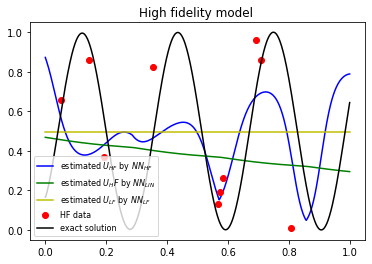

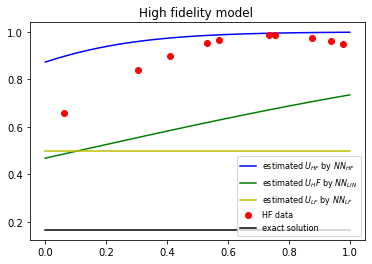

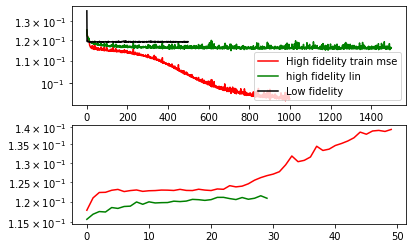

In [26]:
####################    HF GRAPHS    #######################

plt.figure()
index_order=np.argsort(reaction_HF_test[:,0])
index_order_HF=np.argsort(reaction_HF[:,0])  
index_order_LF=np.argsort(reaction_LF[:,0])   

mask1_test=np.where(reaction_HF_test[:,0]==reaction_HF_test[:,0][index_order[2]])
mask1=np.where(reaction_LF_test[:,0]==np.min(reaction_LF_test[:,0]))
mask1_HF=np.where(reaction_HF[:,0]==reaction_HF[:,0][index_order_HF[2]])
mask1_LF=np.where(reaction_LF[:,0]==reaction_LF[:,0][index_order_LF[2]])
order=np.argsort(reaction_LF[mask1_HF,1])

plt.plot(reaction_HF_test[mask1_test,1].T, UHF[mask1_test], "b-", linewidth=1.5, label="estimated $U_{HF}$ by $NN_{HF}$",)
plt.plot(reaction_HF_test[mask1_test,1].T, U_Lin[mask1_test], "g-", label="estimated $U_HF$ by $NN_{LIN}$")
plt.plot(
    reaction_HF_test[mask1_test,1].T,
    modelLF.predict(reaction_HF_test)[mask1_test],
    "y-",
    label="estimated $U_{LF}$ by $NN_{LF}$",
)
plt.plot(reaction_HF[mask1_HF,1].T, U_HF[mask1_HF], "ro", label="HF data")
plt.plot(reaction_HF_test[mask1_test,1].T, U_HF_test[mask1_test], "k-", label="exact solution")
plt.title("High fidelity model ")
plt.legend(prop={"size": 8})


plt.figure()
index_order=np.argsort(reaction_HF_test[:,1])
index_order_HF=np.argsort(reaction_HF[:,1])  
index_order_LF=np.argsort(reaction_LF[:,1])   

mask1_test=np.where(reaction_HF_test[:,1]==reaction_HF_test[:,1][index_order[2]])
mask1=np.where(reaction_LF_test[:,1]==np.min(reaction_LF_test[:,1]))
mask1_HF=np.where(reaction_HF[:,1]==reaction_HF[:,1][index_order_HF[2]])
mask1_LF=np.where(reaction_LF[:,1]==reaction_LF[:,1][index_order_LF[2]])
order=np.argsort(reaction_LF[mask1_HF,0])


plt.plot(reaction_HF_test[mask1_test,0].T, UHF[mask1_test], "b-", linewidth=1.5, label="estimated $U_{HF}$ by $NN_{HF}$",)
plt.plot(reaction_HF_test[mask1_test,0].T, U_Lin[mask1_test], "g-", label="estimated $U_HF$ by $NN_{LIN}$")
plt.plot(
    reaction_HF_test[mask1_test,0].T,
    modelLF.predict(reaction_HF_test)[mask1_test],
    "y-",
    label="estimated $U_{LF}$ by $NN_{LF}$",
)
plt.plot(reaction_HF[mask1_HF,0].T, U_HF[mask1_HF], "ro", label="HF data")
plt.plot(reaction_HF_test[mask1_test,0].T, U_HF_test[mask1_test], "k-", label="exact solution")
plt.title("High fidelity model ")
plt.legend(prop={"size": 8})




# plt.figure()
# plt.plot(
#     reaction_HF_test,
#     UHF,
#     "ko",
#     label="estimated $U_{HF}$ by $NN_{HF}$",
#     linewidth=3,
# )
# plt.plot(reaction_HF_test, U_Lin, "go", label="estimated $U_HF$ by $NN_{LIN}$")
# plt.plot(
#     reaction_HF_test,
#     modelLF.predict(reaction_HF_test),
#     "bo",
#     label="estimated $U_{LF}$ by $NN_{LF}$",
# )
# plt.plot(reaction_HF, U_HF, "ro", label="HF data")
# plt.plot(reaction_HF_test, U_HF_test, "yo", label="exact solution")
# plt.title("High fidelity model ")
# plt.legend(prop={"size": 8})

####################    TRAINING INSIGHTS    #######################
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(hist.history["mse"], color="red", label="High fidelity train mse")
plt.plot(histLin.history["mse"], color="green", label="high fidelity lin")
plt.plot(histLF.history["mse"], color="black", label="Low fidelity")
plt.legend()
plt.yscale("log")
plt.subplot(2, 1, 2)
plt.plot(hist.history["val_mse"], color="red")
plt.plot(histLin.history["val_mse"], color="green")
plt.yscale("log")
